# Compare Model Output to Global Flood Database

## Prepare GDF data

In [128]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [129]:
GDF_DATA = Path() / "../data/gfd_event_stats_20215_13_error_fixed_2.csv"
GDF_DATA = GDF_DATA.resolve()

gdf = pd.read_csv(GDF_DATA)
gdf.shape

(913, 23)

In [130]:
gdf.head()

,system:index,index,threshold_type,glide_index,dfo_country,dfo_other_country,dfo_centroid_x,dfo_centroid_y,dfo_began,dfo_ended,...,dfo_cause,dfo_severity,gfd_area,gfd_exp_ghsl_ts,gfd_exp_ghsl_2000,gfd_exp_ghsl_2015,Errors,dif 2000,dif 2015,error 2000
0,DFO_1586_From_20000218_to_20000301,1586,otsu,0,Australia,0,143.697800,-31.268059,2/18/00,3/1/00,...,Heavy rain,2.0,316.73,38,38,43,1,0,-5,NaN
1,DFO_1587_From_20000217_to_20000311,1587,otsu,0,Madagascar,0,47.295670,-15.782624,2/17/00,3/11/00,...,"Tropical Storm, Surge",1.0,228.50,4594,4594,6855,1,0,-2261,NaN
2,DFO_1595_From_20000405_to_20000425,1595,otsu,0,Romania,Hungary,22.415404,46.763746,4/5/00,4/25/00,...,"Snowmelt, Ice, Rain",2.0,89.10,3093,3093,4618,1,0,-1525,NaN
3,DFO_1614_From_20000711_to_20000810,1614,otsu,0,Thailand,Vietnam,105.063841,11.242567,7/11/00,8/10/00,...,Heavy rain,1.0,4322.47,544758,544758,658643,1,0,-113885,NaN
4,DFO_1627_From_20000830_to_20000910,1627,otsu,0,China,Russia,132.057679,43.773883,8/30/00,9/10/00,...,"Tropical Storm, Surge",1.0,740.33,785363,785363,766309,1,0,19054,1.0


In [131]:
gdf_bgd = gdf[gdf["dfo_country"] == "Bangladesh"]
gdf_bgd

,system:index,index,threshold_type,glide_index,dfo_country,dfo_other_country,dfo_centroid_x,dfo_centroid_y,dfo_began,dfo_ended,...,dfo_cause,dfo_severity,gfd_area,gfd_exp_ghsl_ts,gfd_exp_ghsl_2000,gfd_exp_ghsl_2015,Errors,dif 2000,dif 2015,error 2000
22,DFO_1908_From_20020418_to_20020429,1908,std,0,Bangladesh,0,91.520040,24.981838,4/18/02,4/29/02,...,Dam,1.0,1.47,0,0,0,1,0,0,NaN
133,DFO_2248_From_20030611_to_20031010,2248,std,0,Bangladesh,India,90.853814,26.170616,6/11/03,10/10/03,...,Heavy rain,2.0,79213.43,16822143,16822144,37057874,0,-1,-20235731,NaN
135,DFO_2257_From_20030619_to_20030703,2257,std,0,Bangladesh,0,91.932656,21.923872,6/19/03,7/3/03,...,Heavy rain,1.0,1262.34,231399,231399,253826,1,0,-22427,NaN
199,DFO_2473_From_20040414_to_20040503,2473,std,0,Bangladesh,India,91.694661,24.894242,4/14/04,5/3/04,...,Heavy rain,1.0,10032.44,1543959,1543959,3603254,1,0,-2059295,NaN
252,DFO_2657_From_20050525_to_20050528,2657,std,0,Bangladesh,0,91.642390,24.598004,5/25/05,5/28/05,...,Heavy rain,1.0,5407.34,1033999,1033999,1846378,1,0,-812379,NaN
256,DFO_2676_From_20050623_to_20050630,2676,std,0,Bangladesh,0,89.114530,25.961407,6/23/05,6/30/05,...,Heavy rain,1.0,2491.27,443415,443415,1346659,1,0,-903244,NaN
294,DFO_2747_From_20051003_to_20051022,2747,std,0,Bangladesh,0,88.977022,25.640627,10/3/05,10/22/05,...,Heavy rain,1.0,19555.37,6010585,6010585,12724540,1,0,-6713955,NaN
356,DFO_2961_From_20060824_to_20060920,2961,std,FL-2006-000131-BGD,Bangladesh,0,89.272707,23.229479,8/24/06,9/20/06,...,Heavy rain,1.0,17824.12,3898327,3898329,10471936,0,-2,-6573609,NaN
387,DFO_3097_From_20070611_to_20070624,3097,std,LS-2007-000080-BGD,Bangladesh,NaN,91.953546,22.397464,6/11/07,6/24/07,...,Heavy rain,1.0,20493.38,4536692,4536692,8995159,1,0,-4458467,NaN
412,DFO_3136_From_20070721_to_20071015,3136,std,0,Bangladesh,NaN,91.233643,23.916419,7/21/07,10/15/07,...,Heavy rain,1.0,78785.53,27712991,27712998,55288622,0,-7,-27575631,NaN


In [132]:
for col in ("dfo_began", "dfo_ended"):
    gdf_bgd[col] = gdf_bgd[col].apply(pd.Timestamp)
gdf_bgd["date"] = (
    gdf_bgd["dfo_began"] + (gdf_bgd["dfo_ended"] - gdf_bgd["dfo_began"]) / 2
)
gdf_bgd["date"]

/var/folders/9m/w030_m9j2j5gyjdjczm2tf680000gq/T/ipykernel_1649/89679941.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gdf_bgd[col] = gdf_bgd[col].apply(pd.Timestamp)
/var/folders/9m/w030_m9j2j5gyjdjczm2tf680000gq/T/ipykernel_1649/89679941.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gdf_bgd["date"] = (


22    2002-04-23 12:00:00
133   2003-08-10 12:00:00
135   2003-06-26 00:00:00
199   2004-04-23 12:00:00
252   2005-05-26 12:00:00
256   2005-06-26 12:00:00
294   2005-10-12 12:00:00
356   2006-09-06 12:00:00
387   2007-06-17 12:00:00
412   2007-09-02 00:00:00
456   2007-11-23 00:00:00
514   2008-09-03 12:00:00
544   2009-05-02 12:00:00
548   2009-07-04 12:00:00
575   2010-04-01 12:00:00
607   2010-07-07 00:00:00
617   2010-09-19 12:00:00
623   2010-10-06 12:00:00
649   2011-07-25 00:00:00
768   2014-08-29 12:00:00
847   2016-08-10 00:00:00
865   2017-04-08 12:00:00
878   2017-08-18 00:00:00
Name: date, dtype: datetime64[ns]

In [133]:
river_floods = gdf_bgd[
    gdf_bgd["dfo_cause"].isin(["Heavy rain", "Dam"])  # Ignore coastal floods
    & ~gdf_bgd["dfo_other_country"].isin(
        ["India"]
    )  # India seems to mess up displacement numbers
]
river_floods = river_floods.set_index("date")["dfo_displaced"].resample("YS").sum()
river_floods

date
2002-01-01          0
2003-01-01      20000
2004-01-01          0
2005-01-01     220000
2006-01-01          0
2007-01-01    5080000
2008-01-01     600000
2009-01-01     715000
2010-01-01     740000
2011-01-01      10000
2012-01-01          0
2013-01-01          0
2014-01-01     500000
2015-01-01          0
2016-01-01      25000
2017-01-01     300000
Freq: YS-JAN, Name: dfo_displaced, dtype: int64

In [134]:
river_floods.median(), river_floods.mean()

(22500.0, np.float64(513125.0))

In [135]:
coastal_floods = gdf_bgd[
    ~gdf_bgd["dfo_cause"].isin(["Heavy rain", "Dam"])  # Ignore heavy rain, dam
    & ~gdf_bgd["dfo_other_country"].isin(
        ["India"]
    )  # India seems to mess up displacement numbers
]
coastal_floods = coastal_floods.set_index("date")["dfo_displaced"].resample("1YE").sum()
coastal_floods

date
2007-12-31    3000000
2008-12-31          0
2009-12-31          0
2010-12-31     500000
Freq: YE-DEC, Name: dfo_displaced, dtype: int64

In [136]:
coastal_floods.median(), coastal_floods.mean()

(250000.0, np.float64(875000.0))

### Return Periods

In [137]:
river_floods_rp = river_floods.to_frame()
river_floods_rp["frequency"] = 1.0 / river_floods_rp.shape[0]
river_floods_rp = river_floods_rp.sort_values("dfo_displaced", ascending=False)
river_floods_rp["exceedance_frequency"] = np.cumsum(
    river_floods_rp["frequency"].to_numpy()
)
river_floods_rp["return_period"] = 1 / river_floods_rp["exceedance_frequency"]
river_floods_rp

,dfo_displaced,frequency,exceedance_frequency,return_period
date,,,,
2007-01-01,5080000,0.0625,0.0625,16.000000
2010-01-01,740000,0.0625,0.1250,8.000000
2009-01-01,715000,0.0625,0.1875,5.333333
2008-01-01,600000,0.0625,0.2500,4.000000
2014-01-01,500000,0.0625,0.3125,3.200000
2017-01-01,300000,0.0625,0.3750,2.666667
2005-01-01,220000,0.0625,0.4375,2.285714
2016-01-01,25000,0.0625,0.5000,2.000000
2003-01-01,20000,0.0625,0.5625,1.777778


In [138]:
coastal_floods_rp = coastal_floods.to_frame()
coastal_floods_rp["frequency"] = 1.0 / coastal_floods_rp.shape[0]
coastal_floods_rp = coastal_floods_rp.sort_values("dfo_displaced", ascending=False)
coastal_floods_rp["exceedance_frequency"] = np.cumsum(
    coastal_floods_rp["frequency"].to_numpy()
)
coastal_floods_rp["return_period"] = 1 / coastal_floods_rp["exceedance_frequency"]
coastal_floods_rp

,dfo_displaced,frequency,exceedance_frequency,return_period
date,,,,
2007-12-31,3000000,0.25,0.25,4.000000
2010-12-31,500000,0.25,0.50,2.000000
2008-12-31,0,0.25,0.75,1.333333
2009-12-31,0,0.25,1.00,1.000000


## Prepare results

In [139]:
RESULTS_BGD_RIVERINE_PATH = Path() / "../results/BGD_displacement_riverine.csv"
RESULTS_BGD_COASTAL_PATH = Path() / "../results/BGD_displacement_coastal.csv"

In [140]:
res_river = pd.read_csv(RESULTS_BGD_RIVERINE_PATH)
res_river

,return_period,frequency,displacement_low,displacement_med,displacement_high
0,2,0.500,0.000000e+00,0.000000e+00,0.000000e+00
1,5,0.200,1.291632e+06,1.011106e+06,6.821588e+05
2,10,0.100,2.172145e+06,1.594788e+06,1.224269e+06
3,25,0.040,4.246278e+06,2.604610e+06,1.895893e+06
4,50,0.020,6.083105e+06,3.617706e+06,2.324439e+06
5,100,0.010,8.526230e+06,5.922603e+06,3.123252e+06
6,250,0.004,1.028840e+07,8.451750e+06,5.419664e+06
7,500,0.002,1.151349e+07,9.710770e+06,6.708775e+06
8,1000,0.001,1.312784e+07,1.084802e+07,8.067217e+06
9,AED,NaN,9.296249e+05,6.615411e+05,4.555791e+05


In [141]:
res_coast = pd.read_csv(RESULTS_BGD_COASTAL_PATH)
res_coast

,return_period,frequency,displacement_low,displacement_med,displacement_high
0,2,0.500,8.220780e+05,6.666985e+05,4.815442e+05
1,5,0.200,2.291444e+06,1.867060e+06,1.345191e+06
2,10,0.100,3.525953e+06,2.823392e+06,2.009764e+06
3,25,0.040,5.678444e+06,4.675372e+06,3.277443e+06
4,50,0.020,8.065134e+06,6.633137e+06,4.795887e+06
5,100,0.010,1.028796e+07,8.526897e+06,6.222500e+06
6,250,0.004,1.348890e+07,1.156487e+07,8.261108e+06
7,500,0.002,1.665581e+07,1.441778e+07,1.023062e+07
8,1000,0.001,1.960318e+07,1.733330e+07,1.212435e+07
9,AED,NaN,1.820114e+06,1.486475e+06,1.065657e+06


## Plotting

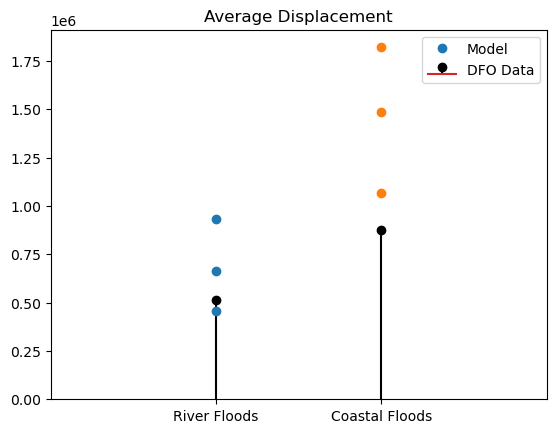

In [142]:
fig, ax = plt.subplots()

x = 0
ax.stem([x], river_floods.mean(), "ko", label="DFO Data")
ax.plot(
    [x, x, x],
    res_river.loc[9, ["displacement_low", "displacement_med", "displacement_high"]],
    "o",
    label="Model",
)

x = 1
ax.stem([x], coastal_floods.mean(), "ko")
ax.plot(
    [x, x, x],
    res_coast.loc[9, ["displacement_low", "displacement_med", "displacement_high"]],
    "o",
)
ax.set_ylim(bottom=0)
ax.set_xlim(-1, 2)
ax.set_xticks([0, 1])
ax.set_xticklabels(["River Floods", "Coastal Floods"])
ax.set_title("Average Displacement")
ax.legend()

Text(0.02, 0.5, 'People Displaced')

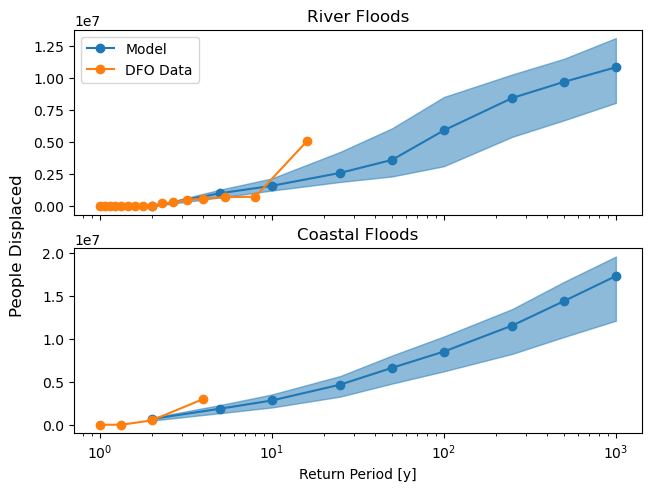

In [143]:
fig, axes = plt.subplots(2, 1, sharex=True, constrained_layout=True)

res_river_plt = res_river.iloc[0:9]
axes[0].fill_between(
    res_river_plt["return_period"].astype("float"),
    res_river_plt["displacement_low"],
    res_river_plt["displacement_high"],
    color="C0",
    alpha=0.5,
)
axes[0].plot(
    res_river_plt["return_period"].astype("float"),
    res_river_plt["displacement_med"],
    "-o",
    label="Model",
)
axes[0].plot(
    river_floods_rp["return_period"],
    river_floods_rp["dfo_displaced"],
    "-o",
    label="DFO Data",
)
axes[0].legend()
axes[0].set_title("River Floods")

res_coast_plt = res_coast.iloc[0:9]
axes[1].fill_between(
    res_coast_plt["return_period"].astype("float"),
    res_coast_plt["displacement_low"],
    res_coast_plt["displacement_high"],
    color="C0",
    alpha=0.5,
)
axes[1].plot(
    res_coast_plt["return_period"].astype("float"),
    res_coast_plt["displacement_med"],
    "-o",
    label="Model",
)
axes[1].plot(
    coastal_floods_rp["return_period"],
    coastal_floods_rp["dfo_displaced"],
    "-o",
    label="DFO Data",
)
axes[1].set_xscale("log")
axes[1].set_xlabel("Return Period [y]")
axes[1].set_title("Coastal Floods")
fig.supylabel("People Displaced")